In [4]:
import pandas as pd
from src.common.utils import get_root_directory
import matplotlib.pyplot as plt
from src.preprocessing.data_loader import DataLoader
from src.common.plotter import Plotter

## Walkforward Sliding-Window

In [2]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.merge_selected_data(selected_data=['sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'D_VADER_AvgScr_In', 'D_VADER_Sent_AvgIn', 'D_VADER_AvgScr_Ex',
       'D_VADER_Sent_AvgEx', 'D_FINBERT_AvgScr_In', 'D_FINBERT_Sent_AvgIn',
       'D_FINBERT_AvgScr_Ex', 'D_FINBERT_Sent_AvgEx', 'D_CRYPTOBERT_AvgScr_In',
       'D_CRYPTOBERT_Sent_AvgIn', 'D_CRYPTOBERT_AvgScr_Ex',
       'D_CRYPTOBERT_Sent_AvgEx'],
      dtype='object')

In [3]:
selected_features = ['ETH_D_AvgPrc', 'ETH_D_PrcDir',
       'D_VADER_AvgScr_In', 'D_VADER_Sent_AvgIn', 'D_VADER_AvgScr_Ex',
       'D_VADER_Sent_AvgEx', 'D_FINBERT_AvgScr_In', 'D_FINBERT_Sent_AvgIn',
       'D_FINBERT_AvgScr_Ex', 'D_FINBERT_Sent_AvgEx', 'D_CRYPTOBERT_AvgScr_In',
       'D_CRYPTOBERT_Sent_AvgIn', 'D_CRYPTOBERT_AvgScr_Ex',
       'D_CRYPTOBERT_Sent_AvgEx']
DL.select_features(features=selected_features)
DL.set_time_range(start_date="01/01/2021", end_date="31/12/2023")
train, test = DL.split_data(split_size=0.15)
train, val = DL.split_data(split_type="train_val", split_size=0.15)
n_periods=7

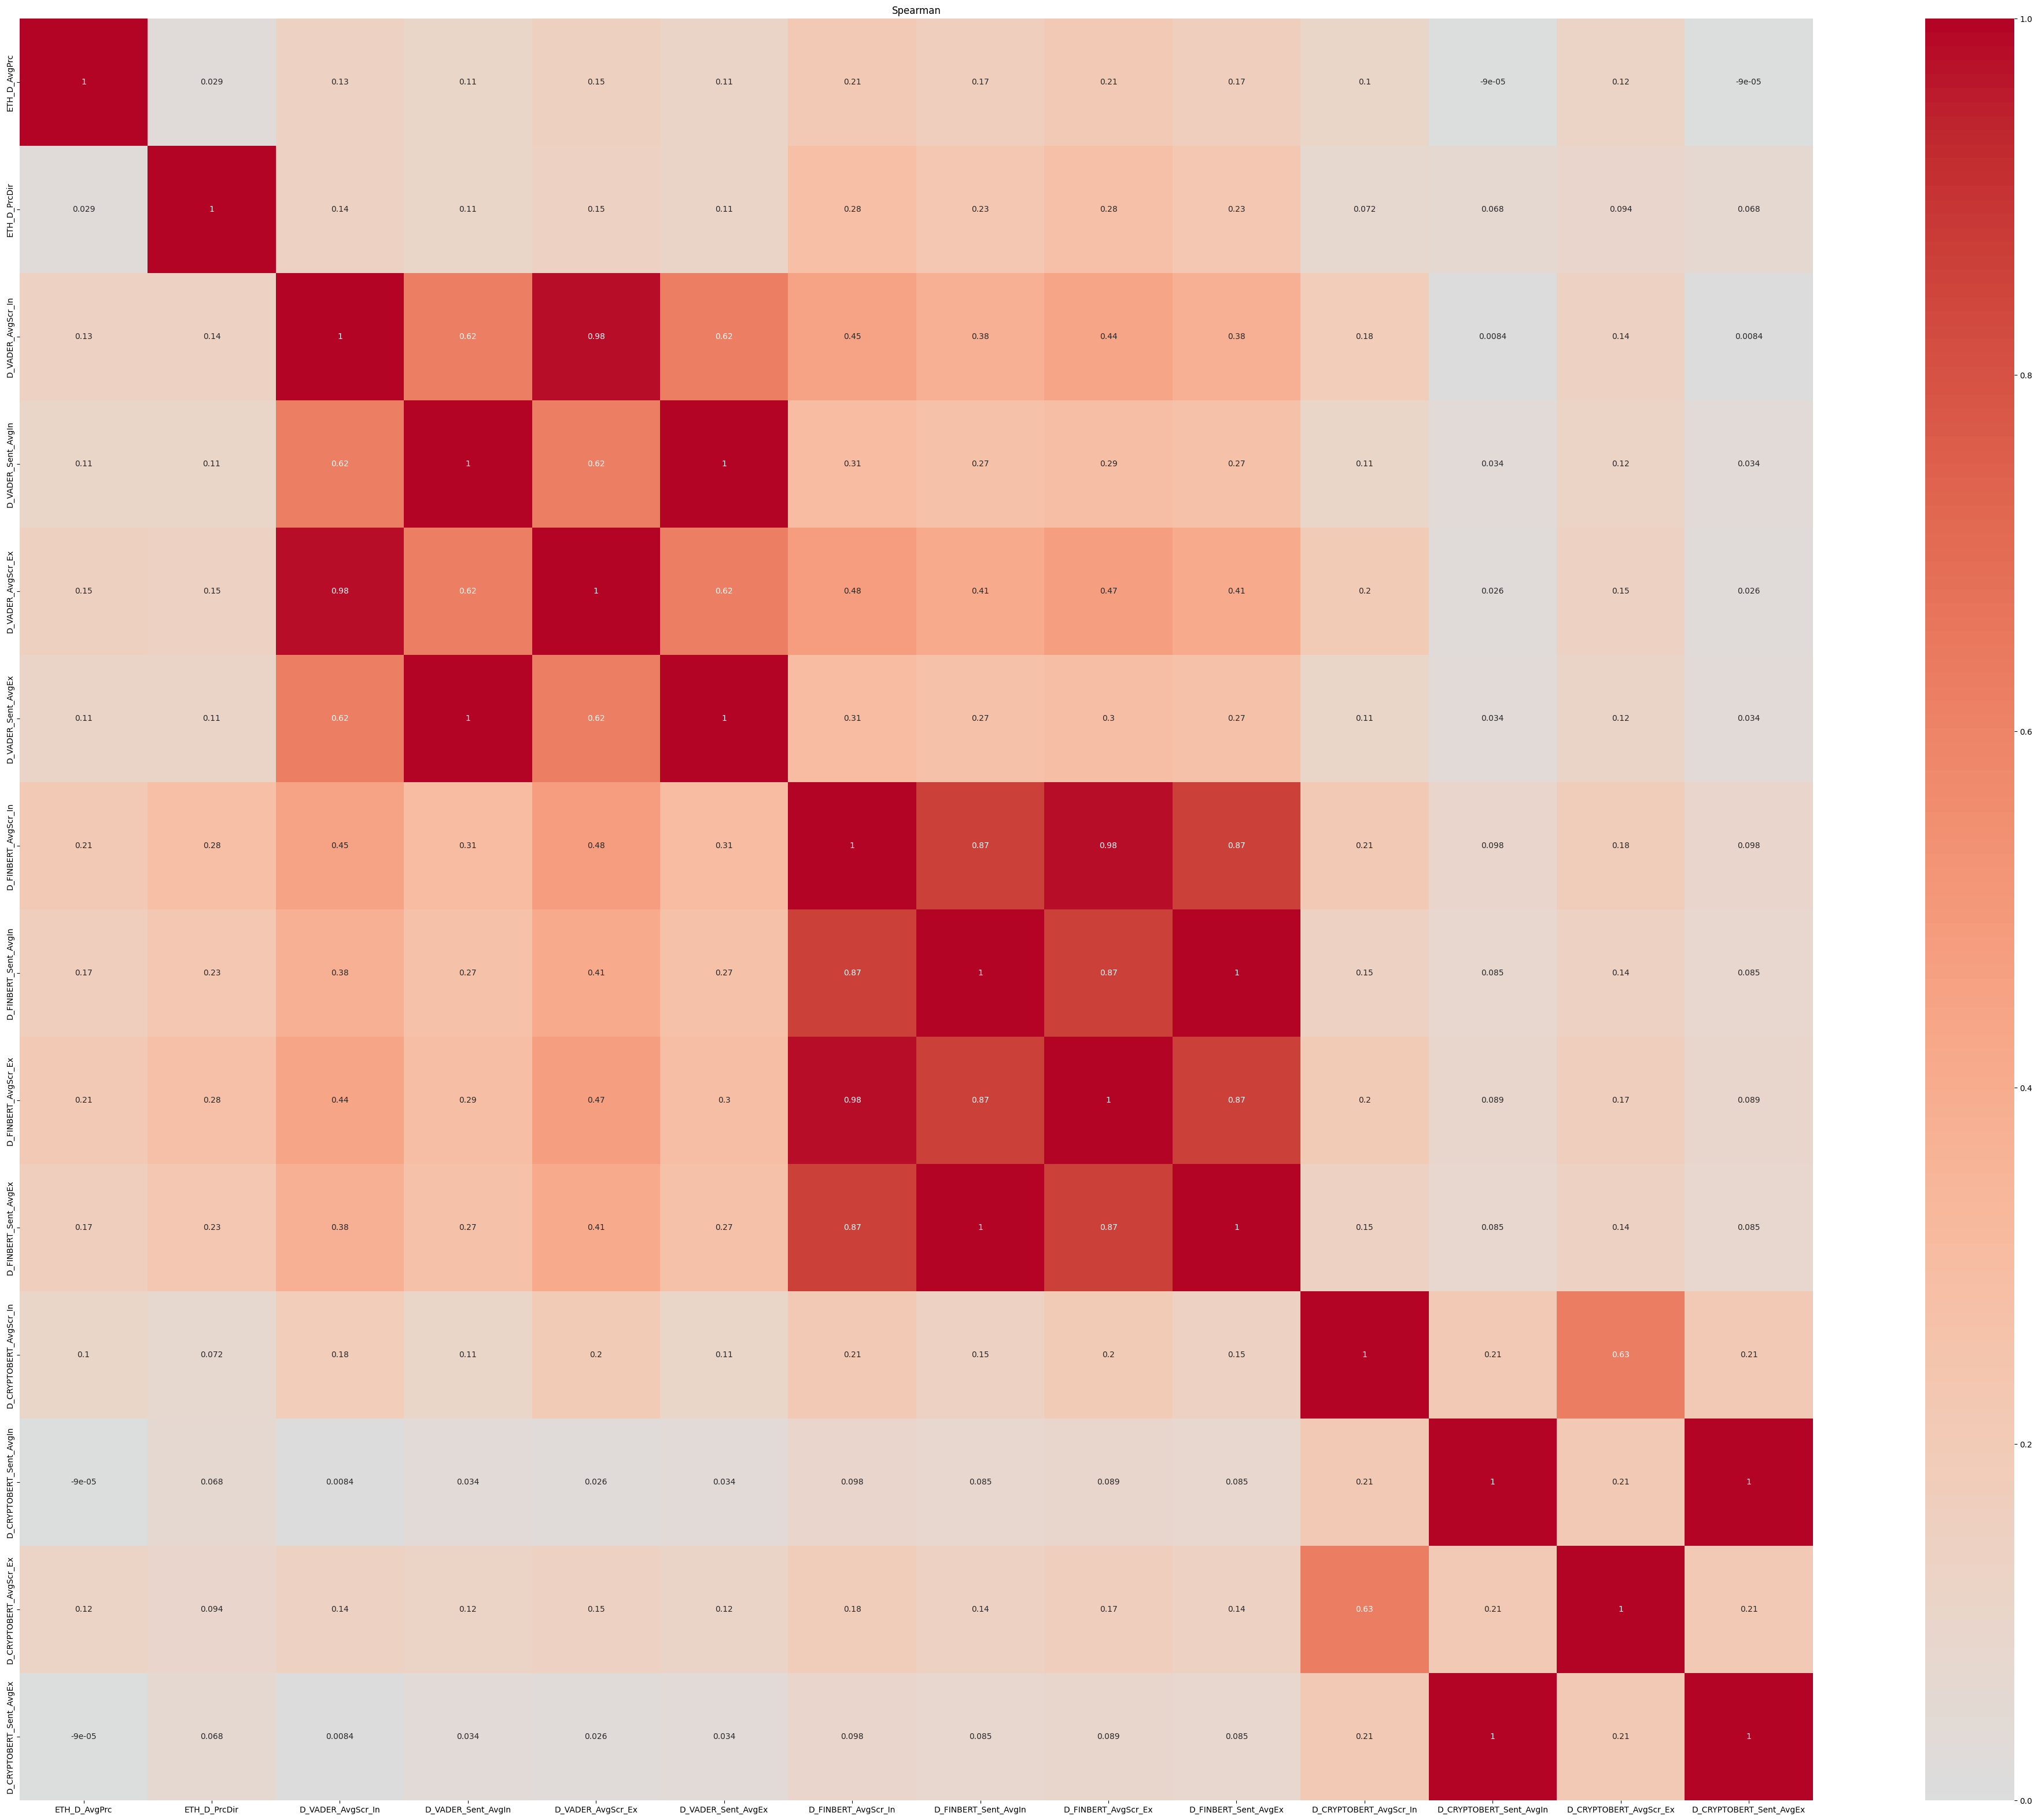

In [6]:
plotter = Plotter(root_dir)
plotter.plot_correlation_matrix(train, method="spearman", figsize=(50,40), title="Spearman")

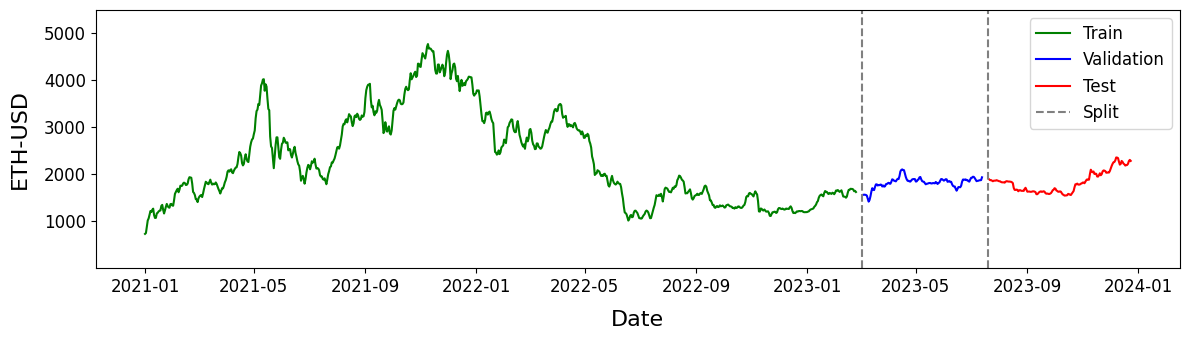

In [8]:
plt.figure(figsize=(12, 3.5))
# plt.fill_between(DL.final_data.index, DL.final_data['ETH_YF_Hi'], DL.final_data['ETH_YF_Lo'], color='skyblue', label='High-Low Range')
plt.plot(train[:-7].index, train['ETH_D_AvgPrc'][:-7].values, label='Train', color='green')
plt.plot(val[:-7].index, val['ETH_D_AvgPrc'][:-7].values, label='Validation', color='blue')
plt.plot(test[:-7].index, test['ETH_D_AvgPrc'][:-7].values, label='Test', color='red')
plt.axvline(train.index[-1], color='gray', linestyle='--', label='Split')
plt.axvline(val.index[-1], color='gray', linestyle='--')
plt.xlabel('Date', fontsize=16,labelpad=10)
plt.ylabel('ETH-USD',fontsize=16,labelpad=10)
plt.ylim(0,5500)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, ticks=[1000,2000,3000,4000,5000]) 
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('test_train_validation.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

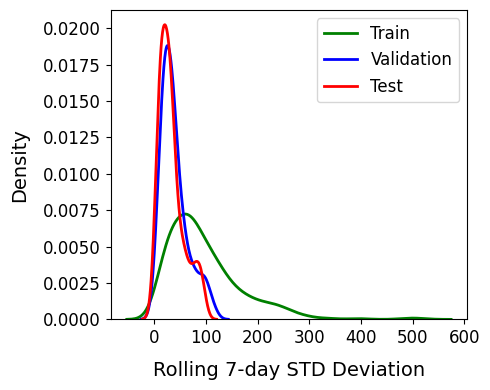

In [83]:
import seaborn as sns

plt.figure(figsize=(5, 4))

# KDE plots
sns.kdeplot(train['ETH_D_AvgPrc'][:-7].rolling(window=7).std(), label='Train', color='green', linewidth=2)
sns.kdeplot( val['ETH_D_AvgPrc'][:-7].rolling(window=7).std(), label='Validation', color='blue', linewidth=2)
sns.kdeplot( test['ETH_D_AvgPrc'][:-7].rolling(window=7).std(), label='Test', color='red', linewidth=2)

# Labels and legend
plt.xlabel('Rolling 7-day STD Deviation', fontsize=14, labelpad=10)
plt.ylabel('Density',fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('splits_distribution.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

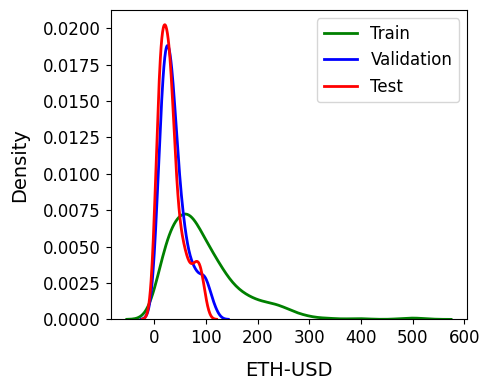

In [76]:
import seaborn as sns

plt.figure(figsize=(5, 4))

# KDE plots
sns.kdeplot(train['ETH_D_AvgPrc'][:-7].rolling(window=7).std(), label='Train', color='green', linewidth=2)
sns.kdeplot( val['ETH_D_AvgPrc'][:-7].rolling(window=7).std(), label='Validation', color='blue', linewidth=2)
sns.kdeplot( test['ETH_D_AvgPrc'][:-7].rolling(window=7).std(), label='Test', color='red', linewidth=2)

# Labels and legend
plt.xlabel('ETH-USD', fontsize=14, labelpad=10)
plt.ylabel('Density',fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig('splits_distribution.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

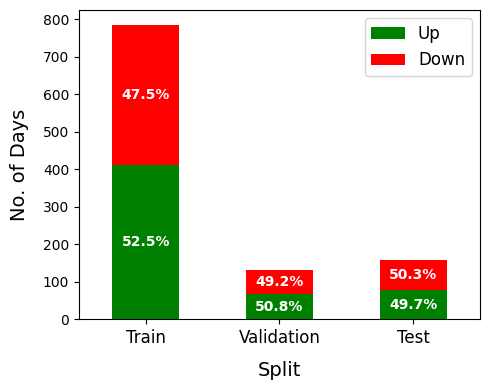

In [66]:
def compute_up_down_counts(df, name):
    df = df.copy()
    df['price_change'] = df['ETH_D_AvgPrc'].diff()
    df['direction'] = df['price_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    
    counts = df['direction'].value_counts()
    total = counts.sum()
    
    return {
        'Up': counts.get('Up', 0),
        'Down': counts.get('Down', 0),
        'Up_pct': (counts.get('Up', 0) / total) * 100,
        'Down_pct': (counts.get('Down', 0) / total) * 100,
        'Split': name
    }

# Compute counts and percentages
train_stats = compute_up_down_counts(train[:-7], 'Train')
val_stats = compute_up_down_counts(val[:-7], 'Validation')
test_stats = compute_up_down_counts(test[:-7], 'Test')

# Create DataFrame
plot_df = pd.DataFrame([train_stats, val_stats, test_stats])
plot_df.set_index('Split', inplace=True)

# Stacked bar chart using actual counts
ax = plot_df[['Up', 'Down']].plot(kind='bar', stacked=True, color=['green', 'red'], figsize=(5, 4))

# Add percentage labels inside bars
for i, (index, row) in enumerate(plot_df.iterrows()):
    up_count = row['Up']
    down_count = row['Down']
    up_pct = row['Up_pct']
    down_pct = row['Down_pct']

    ax.text(i, up_count / 2, f'{up_pct:.1f}%', color='white', ha='center', va='center', fontweight='bold')
    ax.text(i, up_count + down_count / 2, f'{down_pct:.1f}%', color='white', ha='center', va='center', fontweight='bold')

# Styling
plt.ylabel('No. of Days', fontsize=14, labelpad=10)
plt.xlabel('Split', fontsize=14, labelpad=10)
plt.xticks(rotation=0, fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('splits_distribution_classification.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

In [39]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
selected_features = ['ETH_D_AvgPrc', 'ETH_YF_Hi', 'ETH_YF_Lo']
DL.select_features(features=selected_features)
DL.set_time_range(start_date="01/01/2021", end_date="31/12/2023")
train, test = DL.split_data(split_size=0.20)
train, val = DL.split_data(split_type="train_val", split_size=0.20)
n_periods=7

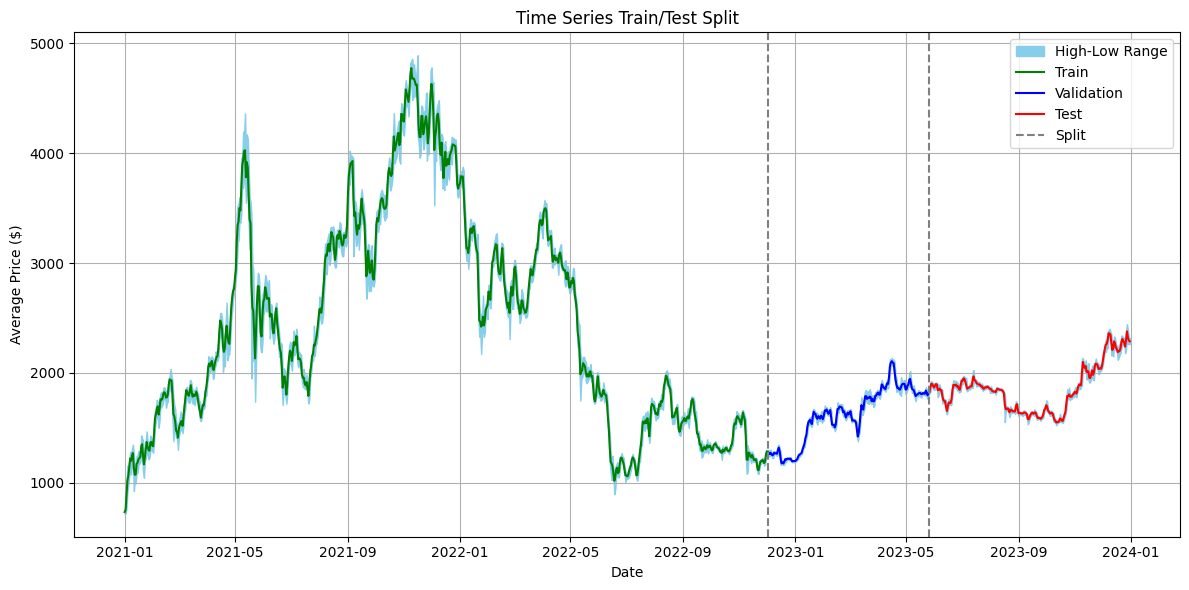

In [40]:
plt.figure(figsize=(12, 6))
plt.fill_between(DL.final_data.index, DL.final_data['ETH_YF_Hi'], DL.final_data['ETH_YF_Lo'], color='skyblue', label='High-Low Range')
plt.plot(train.index, train['ETH_D_AvgPrc'].values, label='Train', color='green')
plt.plot(val.index, val['ETH_D_AvgPrc'].values, label='Validation', color='blue')
plt.plot(test.index, test['ETH_D_AvgPrc'].values, label='Test', color='red')
plt.axvline(train.index[-1], color='gray', linestyle='--', label='Split')
plt.axvline(val.index[-1], color='gray', linestyle='--')
plt.title('Time Series Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

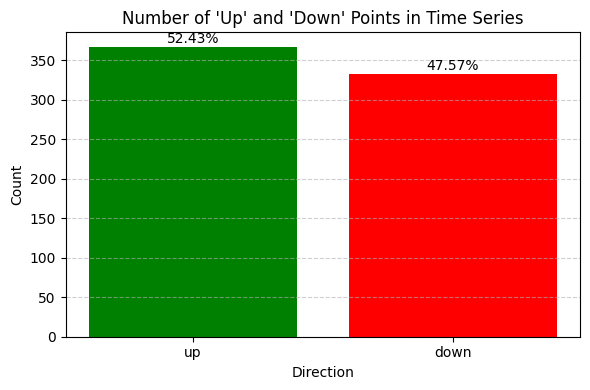

In [41]:
labels = (train['ETH_D_AvgPrc'].shift(-1) > train['ETH_D_AvgPrc']).astype(int)[:-1]

# Optional: convert to string labels
label_names = labels.map({1: 'up', 0: 'down'})

# Count occurrences
label_counts = label_names.value_counts()
total = label_counts.sum()
percentages = (label_counts / total * 100).round(2)

# Plotting
plt.figure(figsize=(6, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=['green', 'red'])

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title("Number of 'Up' and 'Down' Points in Time Series")
plt.xlabel("Direction")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

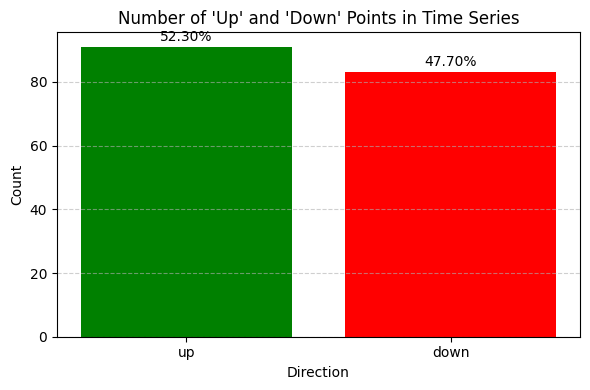

In [42]:
labels = (val['ETH_D_AvgPrc'].shift(-1) > val['ETH_D_AvgPrc']).astype(int)[:-1]

# Optional: convert to string labels
label_names = labels.map({1: 'up', 0: 'down'})

# Count occurrences
label_counts = label_names.value_counts()
total = label_counts.sum()
percentages = (label_counts / total * 100).round(2)

# Plotting
plt.figure(figsize=(6, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=['green', 'red'])

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title("Number of 'Up' and 'Down' Points in Time Series")
plt.xlabel("Direction")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

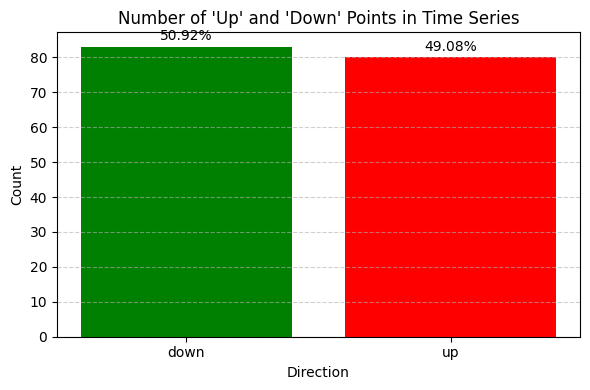

In [38]:
labels = (test['ETH_D_AvgPrc'].shift(-1) > test['ETH_D_AvgPrc']).astype(int)[:-1]

# Optional: convert to string labels
label_names = labels.map({1: 'up', 0: 'down'})

# Count occurrences
label_counts = label_names.value_counts()
total = label_counts.sum()
percentages = (label_counts / total * 100).round(2)

# Plotting
plt.figure(figsize=(6, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=['green', 'red'])

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title("Number of 'Up' and 'Down' Points in Time Series")
plt.xlabel("Direction")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()